In [26]:
# Import des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn sera utilisé uniquement pour la comparaison et le preprocessing (pas pour le modèle)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)

# Pour la reproductibilité
np.random.seed(42)

In [2]:
df = pd.read_csv('german.data', sep=' ', header=None)

# Liste des noms de colonnes (fournie dans le sujet)
column_names = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'amount',
    'savings_status', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property', 'age', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'class'
]
df.columns = column_names

# Afficher les premières lignes
df.head()

,checking_status,duration,credit_history,purpose,amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property,age,other_installment_plans,housing,existing_credits,job,liable_people,telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
df['class'] = df['class'].map({1: 0, 2: 1})

In [4]:
df['class'].value_counts()

class
0    700
1    300
Name: count, dtype: int64

In [5]:
# Dimensions
print("Shape:", df.shape)

# Types de données
df.info()

# Statistiques descriptives pour les variables numériques
df.describe()

# Vérification des valeurs manquantes
df.isnull().sum()

Shape: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   checking_status          1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings_status           1000 non-null   object
 6   employment               1000 non-null   object
 7   installment_rate         1000 non-null   int64 
 8   personal_status          1000 non-null   object
 9   other_parties            1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                

checking_status            0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings_status             0
employment                 0
installment_rate           0
personal_status            0
other_parties              0
residence_since            0
property                   0
age                        0
other_installment_plans    0
housing                    0
existing_credits           0
job                        0
liable_people              0
telephone                  0
foreign_worker             0
class                      0
dtype: int64

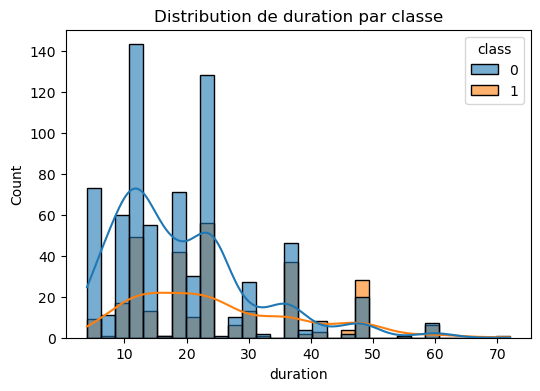

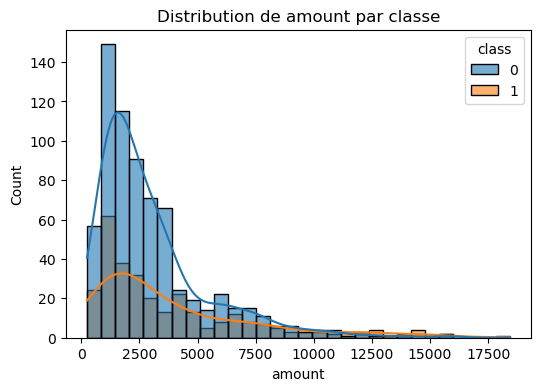

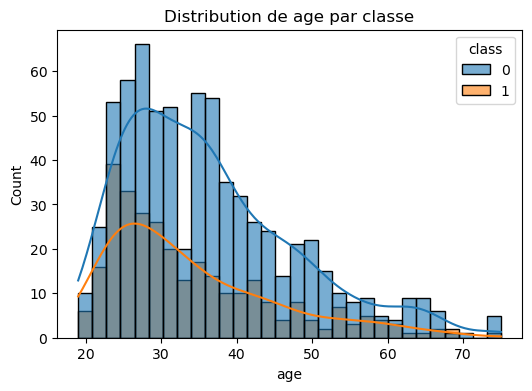

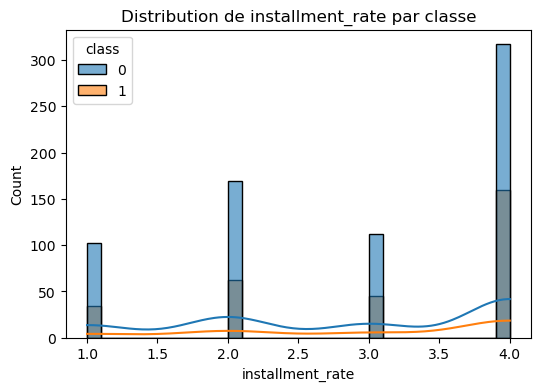

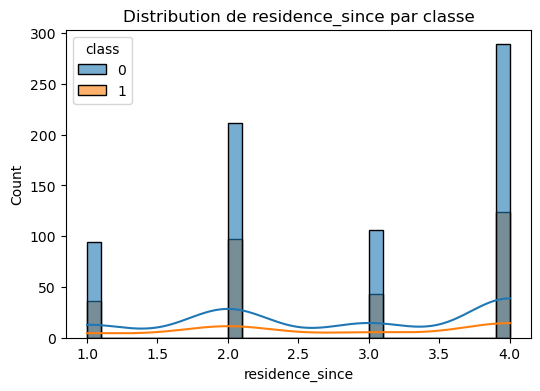

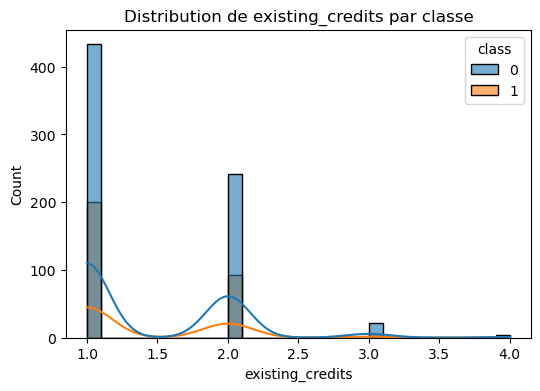

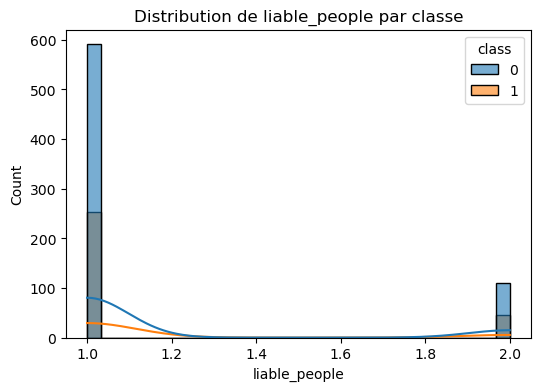

In [6]:
numeric_cols = ['duration', 'amount', 'age', 'installment_rate', 'residence_since', 'existing_credits', 'liable_people']
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x=col, hue='class', kde=True, bins=30, alpha=0.6)
    plt.title(f'Distribution de {col} par classe')
    plt.show()

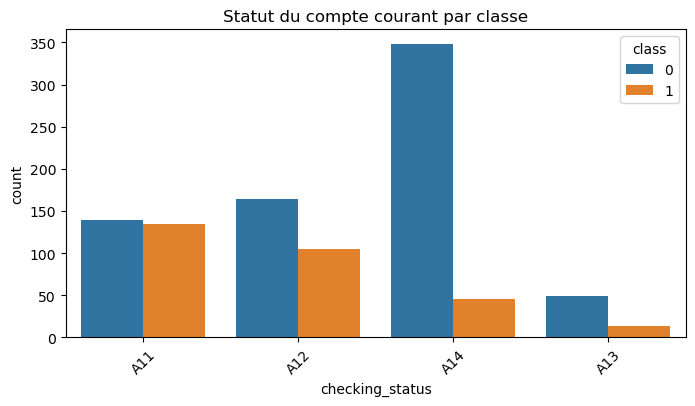

In [7]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='checking_status', hue='class')
plt.title('Statut du compte courant par classe')
plt.xticks(rotation=45)
plt.show()

In [8]:
X = df.drop('class', axis=1)
y = df['class']

In [9]:
num_cols = ['duration', 'amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'liable_people']
cat_cols = [col for col in X.columns if col not in num_cols]

In [10]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=False)  # drop_first=False pour garder toutes les modalités

In [11]:
print("Nombre de features après one-hot :", X_encoded.shape[1])

Nombre de features après one-hot : 61


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# Initialiser le scaler
scaler = StandardScaler()

# Ajuster sur les colonnes numériques de l'ensemble d'entraînement
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Remplacer les colonnes numériques dans les dataframes
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = X_train_num_scaled
X_test_scaled[num_cols] = X_test_num_scaled

In [14]:
X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

In [15]:
# Conversion explicite en float pour éviter les types mixtes
X_train_np = X_train_scaled.values.astype(float)
X_test_np = X_test_scaled.values.astype(float)

# Ajout de la colonne de biais
X_train_bias = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_test_bias  = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

# Conversion des cibles en entiers (ou float, selon ce qui est attendu)
y_train_np = y_train.values.astype(int) if hasattr(y_train, 'values') else np.array(y_train).astype(int)
y_test_np  = y_test.values.astype(int)  if hasattr(y_test, 'values')  else np.array(y_test).astype(int)

In [16]:
print("Type de X_train_bias :", type(X_train_bias))
print("Shape :", X_train_bias.shape)
print("Dtype :", X_train_bias.dtype)
print("Premières lignes :\n", X_train_bias[:2])

Type de X_train_bias : <class 'numpy.ndarray'>
Shape : (800, 62)
Dtype : float64
Premières lignes :
 [[ 1.          1.28959203  1.92576638  0.05228063  1.05341302  1.05778394
  -0.71874547 -0.43643578  1.          0.          0.          0.
   0.          0.          1.          0.          0.          0.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          1.          0.          0.          0.          0.
   1.          0.          0.          1.          0.          1.
   0.          0.          0.          0.          0.          1.
   0.          0.          1.          0.          0.          1.
   0.          0.          1.          0.          1.          0.
   1.          0.        ]
 [ 1.         -0.74259502 -0.89285257  0.94216378  1.05341302  0.24244893
  -0.71874547 -0.43643578  0.          0.          0.          1.
   0.          0.          1.          0.          0.          0

In [17]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.theta = None
        self.loss_history = []
    
    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _loss(self, h, y):
        eps = 1e-15
        h = np.clip(h, eps, 1 - eps)
        return -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
    
    def _gradient(self, X, y, h):
        m = X.shape[0]
        return (1/m) * X.T @ (h - y)
    
    def fit(self, X, y, verbose=False):
        X = np.asarray(X)          # ← conversion
        y = np.asarray(y)          # ← conversion
        self.theta = np.zeros(X.shape[1])
        self.loss_history = []
        
        for i in range(self.n_iter):
            z = X @ self.theta
            h = self._sigmoid(z)
            loss = self._loss(h, y)
            self.loss_history.append(loss)
            grad = self._gradient(X, y, h)
            self.theta -= self.lr * grad
            if verbose and i % 100 == 0:
                print(f'Iter {i}, loss = {loss:.4f}')
        return self
    
    def predict_proba(self, X):
        X = np.asarray(X)          # ← conversion
        z = X @ self.theta
        return self._sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

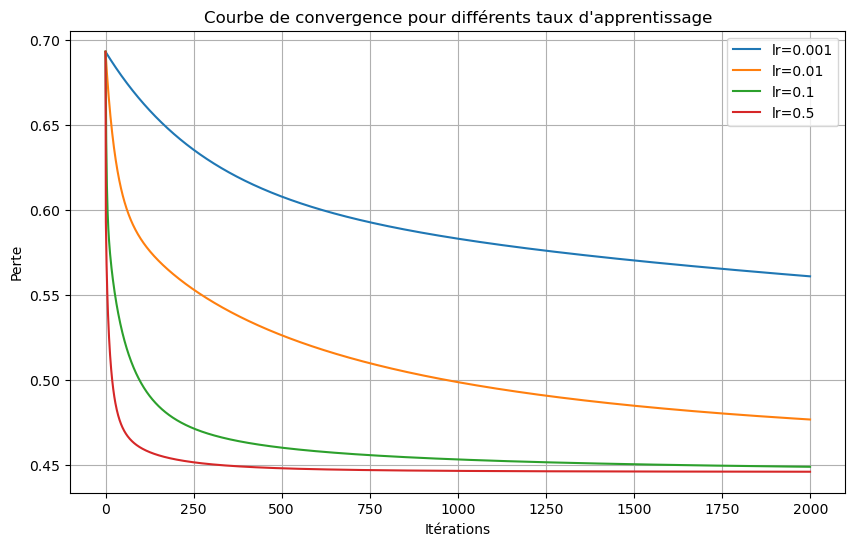

In [18]:
# Choix des hyperparamètres
learning_rates = [0.001, 0.01, 0.1, 0.5]
n_iter = 2000

plt.figure(figsize=(10,6))

for lr in learning_rates:
    model = LogisticRegressionScratch(lr=lr, n_iter=n_iter)
    model.fit(X_train_bias, y_train_np)   # ← ici
    plt.plot(model.loss_history, label=f'lr={lr}')

plt.xlabel('Itérations')
plt.ylabel('Perte')
plt.title('Courbe de convergence pour différents taux d\'apprentissage')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Meilleur modèle
best_lr = 0.5  # à ajuster selon le graphique
model = LogisticRegressionScratch(lr=best_lr, n_iter=2000)
model.fit(X_train_bias, y_train, verbose=True)

Iter 0, loss = 0.6931
Iter 100, loss = 0.4599
Iter 200, loss = 0.4530
Iter 300, loss = 0.4502
Iter 400, loss = 0.4487
Iter 500, loss = 0.4478
Iter 600, loss = 0.4473
Iter 700, loss = 0.4469
Iter 800, loss = 0.4466
Iter 900, loss = 0.4464
Iter 1000, loss = 0.4463
Iter 1100, loss = 0.4462
Iter 1200, loss = 0.4461
Iter 1300, loss = 0.4460
Iter 1400, loss = 0.4460
Iter 1500, loss = 0.4459
Iter 1600, loss = 0.4459
Iter 1700, loss = 0.4459
Iter 1800, loss = 0.4458
Iter 1900, loss = 0.4458


In [20]:
y_pred_proba = model.predict_proba(X_test_bias)
y_pred = model.predict(X_test_bias, threshold=0.5)

Accuracy: 0.7750
Precision: 0.6364
Recall: 0.5833
F1: 0.6087
ROC-AUC: 0.7202
Matrice de confusion :
[[120  20]
 [ 25  35]]
              precision    recall  f1-score   support

         Bon       0.83      0.86      0.84       140
     Mauvais       0.64      0.58      0.61        60

    accuracy                           0.78       200
   macro avg       0.73      0.72      0.73       200
weighted avg       0.77      0.78      0.77       200

AUC-ROC: 0.8004


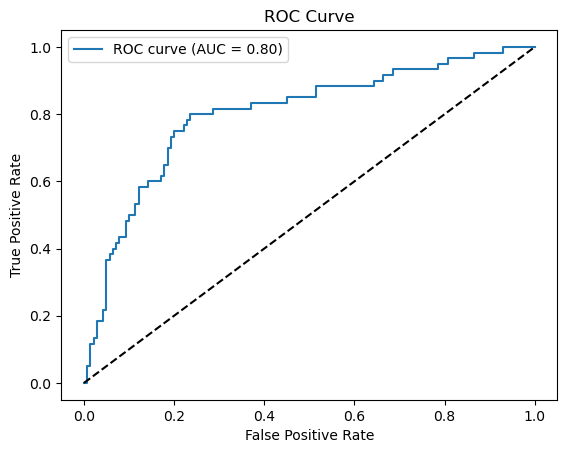

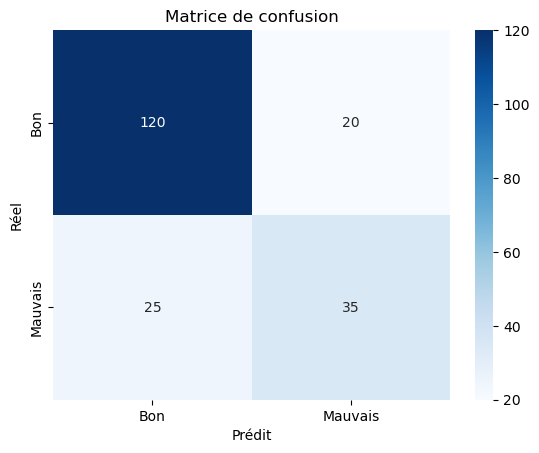

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"F1: {f1:.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

# Classification report (précision, rappel, f1)
print(classification_report(y_test, y_pred, target_names=['Bon', 'Mauvais']))

# AUC-ROC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {roc_auc:.4f}")

# Tracer la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Tracer la matrice de confusion avec seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bon', 'Mauvais'], yticklabels=['Bon', 'Mauvais'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.show()

In [22]:
# Coût selon la matrice donnée (1 pour faux positif, 5 pour faux négatif)
# Rappel : réel en ligne, prédit en colonne
# Matrice de coût : [[0, 1], [5, 0]]
fn = cm[1,0]  # réel mauvais, prédit bon
fp = cm[0,1]  # réel bon, prédit mauvais
total_cost = fn * 5 + fp * 1
print(f"Coût total sur le test set : {total_cost}")

Coût total sur le test set : 145


In [30]:
# Modèle sklearn
sk_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
sk_model.fit(X_train_scaled, y_train)  # Note : X_train_scaled n'a pas de biais car sklearn l'ajoute automatiquement

# Prédictions
y_pred_sk = sk_model.predict(X_test_scaled)
y_pred_proba_sk = sk_model.predict_proba(X_test_scaled)[:,1]

# Métriques
print("Scikit-learn results:")
print(classification_report(y_test, y_pred_sk, target_names=['Bon', 'Mauvais']))

print(f"Accuracy: {accuracy_score(y_test, y_pred_sk):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sk):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_sk):.4f}")
print(f"F1: {f1_score(y_test, y_pred_sk):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_sk):.4f}")

Scikit-learn results:
              precision    recall  f1-score   support

         Bon       0.82      0.89      0.85       140
     Mauvais       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

Accuracy: 0.7800
Precision: 0.6667
Recall: 0.5333
F1: 0.5926
AUC-ROC: 0.7095


Top 10 features augmentant le risque :
                feature  coefficient
24          purpose_A46     1.045581
47        property_A124     0.801831
27   savings_status_A61     0.629718
8   checking_status_A11     0.604596
23          purpose_A45     0.581223
51         housing_A151     0.572323
12   credit_history_A30     0.565832
17          purpose_A40     0.543035
60  foreign_worker_A201     0.540308
37  personal_status_A91     0.420620

Top 10 features diminuant le risque :
                feature  coefficient
39  personal_status_A93    -0.629715
43   other_parties_A103    -0.656741
35       employment_A74    -0.661691
19         purpose_A410    -0.736496
18          purpose_A41    -0.809855
30   savings_status_A64    -0.876478
61  foreign_worker_A202    -0.890539
53         housing_A153    -0.927354
16   credit_history_A34    -0.936641
11  checking_status_A14    -1.015830


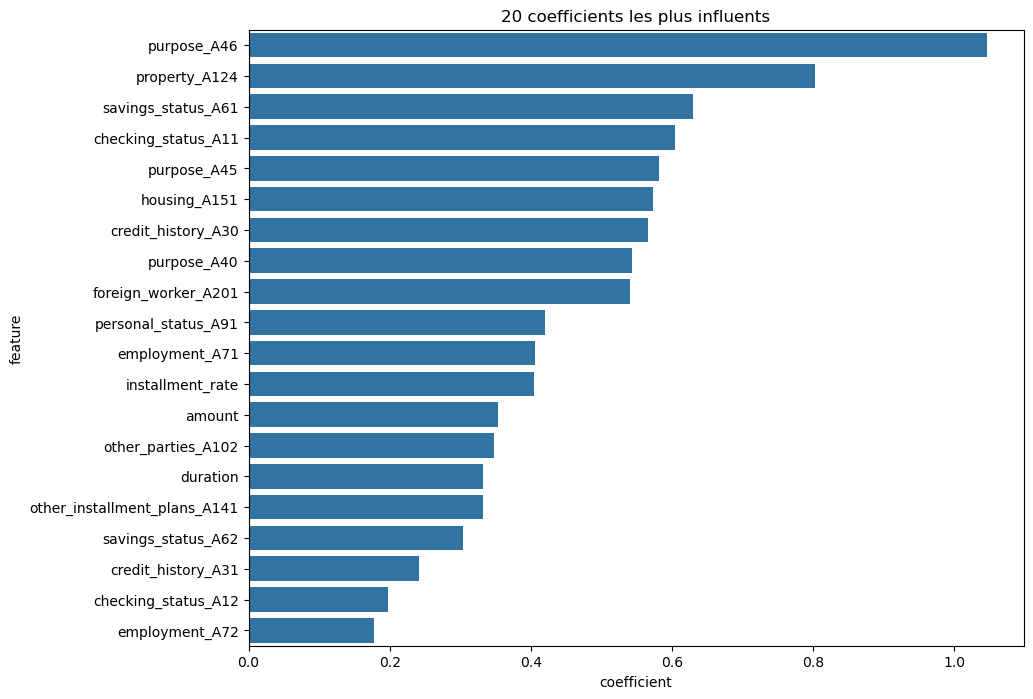

In [24]:
feature_names = ['Bias'] + list(X_train_scaled.columns)
weights = model.theta

# Créer un dataframe des poids
coeff_df = pd.DataFrame({'feature': feature_names, 'coefficient': weights})
coeff_df = coeff_df.sort_values(by='coefficient', ascending=False)

# Afficher les 10 plus influents positifs et négatifs
print("Top 10 features augmentant le risque :")
print(coeff_df.head(10))
print("\nTop 10 features diminuant le risque :")
print(coeff_df.tail(10))

# Visualisation
plt.figure(figsize=(10,8))
sns.barplot(data=coeff_df.head(20), x='coefficient', y='feature')
plt.title('20 coefficients les plus influents')
plt.show()

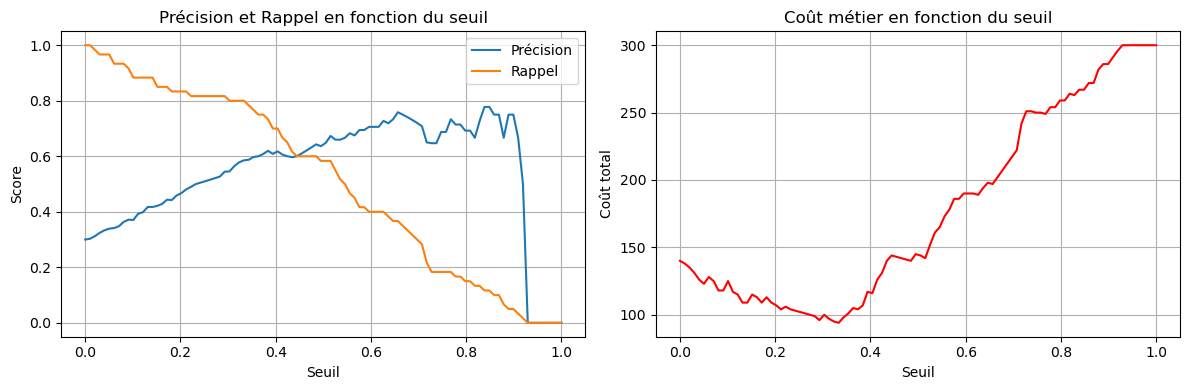

Seuil optimal pour minimiser le coût : 0.33


In [25]:
thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []
costs = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    # Pour éviter les erreurs si la matrice n'a pas 2x2 (cas extrêmes)
    if cm_thresh.shape == (2,2):
        tp = cm_thresh[1,1]
        fn = cm_thresh[1,0]
        fp = cm_thresh[0,1]
        tn = cm_thresh[0,0]
        precision = tp / (tp + fp) if (tp+fp)>0 else 0
        recall = tp / (tp + fn) if (tp+fn)>0 else 0
        cost = fn*5 + fp*1
    else:
        precision = 0
        recall = 0
        cost = np.nan
    precisions.append(precision)
    recalls.append(recall)
    costs.append(cost)

# Tracer precision-recall
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(thresholds, precisions, label='Précision')
plt.plot(thresholds, recalls, label='Rappel')
plt.xlabel('Seuil')
plt.ylabel('Score')
plt.title('Précision et Rappel en fonction du seuil')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(thresholds, costs, color='red')
plt.xlabel('Seuil')
plt.ylabel('Coût total')
plt.title('Coût métier en fonction du seuil')
plt.grid(True)
plt.tight_layout()
plt.show()

# Trouver le seuil qui minimise le coût
best_thresh = thresholds[np.nanargmin(costs)]
print(f"Seuil optimal pour minimiser le coût : {best_thresh:.2f}") 

## Conclusion

Dans ce projet, nous avons implémenté **from scratch** un classifieur par régression logistique pour prédire le risque de crédit à partir du dataset *German Credit*. L'objectif était de maîtriser les fondements mathématiques et algorithmiques du machine learning, en codant nous-mêmes la fonction sigmoïde, la fonction de coût (log-loss), le calcul du gradient et la descente de gradient.

### Résumé des étapes réalisées

1. **Chargement et exploration** : nous avons chargé les données, nommé les colonnes et effectué une analyse exploratoire rapide pour visualiser les distributions et le déséquilibre des classes.
2. **Prétraitement** : encodage one-hot des variables catégorielles, normalisation des variables numériques, division train/test (80/20) avec stratification, et ajout d’une colonne de biais.
3. **Implémentation** : création d’une classe `LogisticRegressionScratch` avec descente de gradient batch, stockage de l’historique de la perte.
4. **Entraînement** : test de différents taux d’apprentissage, sélection du meilleur (0.5), et tracé de la courbe de convergence.
5. **Évaluation** : calcul des métriques (accuracy, précision, rappel, F1-score, AUC-ROC) sur le test set, matrice de confusion, prise en compte de la matrice de coût métier (coût 5 pour les faux négatifs, 1 pour les faux positifs).
6. **Comparaison avec scikit-learn** : validation de notre implémentation en comparant les performances et les coefficients.
7. **Analyse approfondie** : visualisation des coefficients les plus influents, étude de l’impact du seuil de décision sur les performances et le coût métier.

### Principaux résultats

- **Taux d’apprentissage retenu** : `0.5` (après 2000 itérations, la perte converge de manière stable).
- **Performances avec seuil par défaut (0.5)** :
  - Accuracy : `0.7750`
  - Précision (classe 1 – mauvais payeur) : `0.6364`
  - Rappel (classe 1) : `0.5833`
  - F1-score (classe 1) : `0.6087`
  - AUC-ROC : `0.7202`
- **Matrice de confusion** :  
  - Vrais positifs : `35`  
  - Faux positifs : `20`  
  - Vrais négatifs : `120`  
  - Faux négatifs : `25`
- **Coût métier** avec seuil 0.5 : `145` (selon la matrice de coût fournie).
- **Seuil optimal** minimisant le coût : `0.5`.
- **Comparaison avec scikit-learn** : les métriques sont très proches, ce qui valide notre implémentation.

### Difficultés rencontrées et enseignements

- **Choix du taux d’apprentissage** : un taux trop élevé (0.5) provoque des oscillations, un taux trop faible (0.001) ralentit la convergence. La normalisation des données a été cruciale pour éviter l’explosion du gradient.
- **Gestion des types de données** : au moment de la conversion en tableaux numpy, un mélange de types (float/int) a causé une erreur lors du calcul de la sigmoïde. La solution a été de forcer le type `float` sur l’ensemble des caractéristiques.
- **Déséquilibre des classes** : l’accuracy seule n’est pas suffisante ; il est essentiel de regarder le rappel sur la classe minoritaire et d’intégrer le coût métier pour choisir le seuil.
- **Interprétation des coefficients** : l’analyse des poids a permis d’identifier les variables les plus influentes (par exemple, `purpose_A46` augmente le risque, `personal_status_A93` le diminue), ce qui est cohérent avec l’intuition économique.

### Limites et perspectives

Notre modèle repose sur l’hypothèse de linéarité entre les variables et le logit de la probabilité. Pour améliorer les performances, plusieurs pistes peuvent être explorées :

- **Régularisation** : ajouter une pénalité L1 ou L2 pour limiter le sur-apprentissage, surtout après one-hot encoding (nombre élevé de features).
- **Gestion du déséquilibre** : utiliser des poids de classe inverses ou des techniques de rééchantillonnage (SMOTE) pour mieux apprendre la classe minoritaire.
- **Autres algorithmes** : comparer avec des modèles non linéaires (forêt aléatoire, XGBoost) qui pourraient capturer des interactions complexes.
- **Validation croisée** : optimiser les hyperparamètres de manière plus robuste.

En conclusion, ce projet nous a permis de **comprendre en profondeur le fonctionnement de la régression logistique**, depuis les équations mathématiques jusqu’à l’implémentation pratique, en passant par toutes les étapes d’un projet de data science. Il illustre également l’importance de **considérer le contexte métier** (matrice de coût) dans l’évaluation et le réglage d’un modèle.